
Dataset 1


C:\Users\altyyevaa\AppData\Local\Temp\ipykernel_5028\1274974057.py:53: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(np.abs(P_fine - Tc), t_fine)


  E (Full Lagrange, all pts):     2152729053290047416502420347109000426672266767321499673801506846363166335465764683776.00 °F·s
  E (Lagrange, first 30 pts):     416815.15 °F·s  [over first 290s only]
  E (Lagrange, first 10 pts):     429.01 °F·s  [over first 90s only]
  E (Piecewise Lagrange deg=3):   15977.74 °F·s


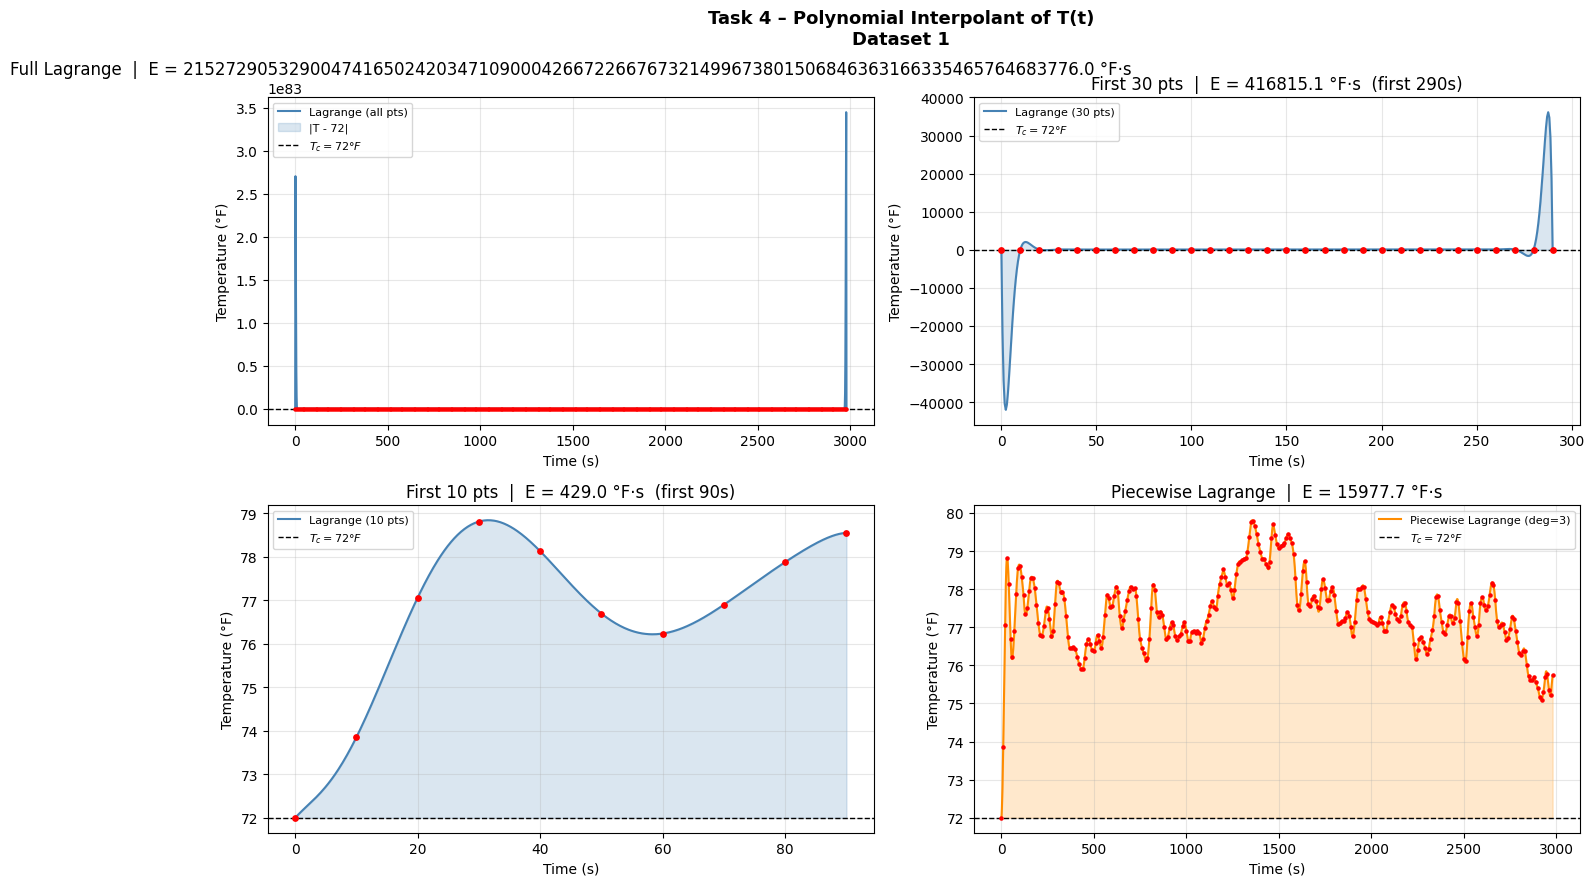


Dataset 2
  E (Full Lagrange, all pts):     3001002083474854744644993833601249976755877755973856258571907405230890599981898530816.00 °F·s
  E (Lagrange, first 30 pts):     17880.74 °F·s  [over first 290s only]
  E (Lagrange, first 10 pts):     688.75 °F·s  [over first 90s only]
  E (Piecewise Lagrange deg=3):   31922.07 °F·s


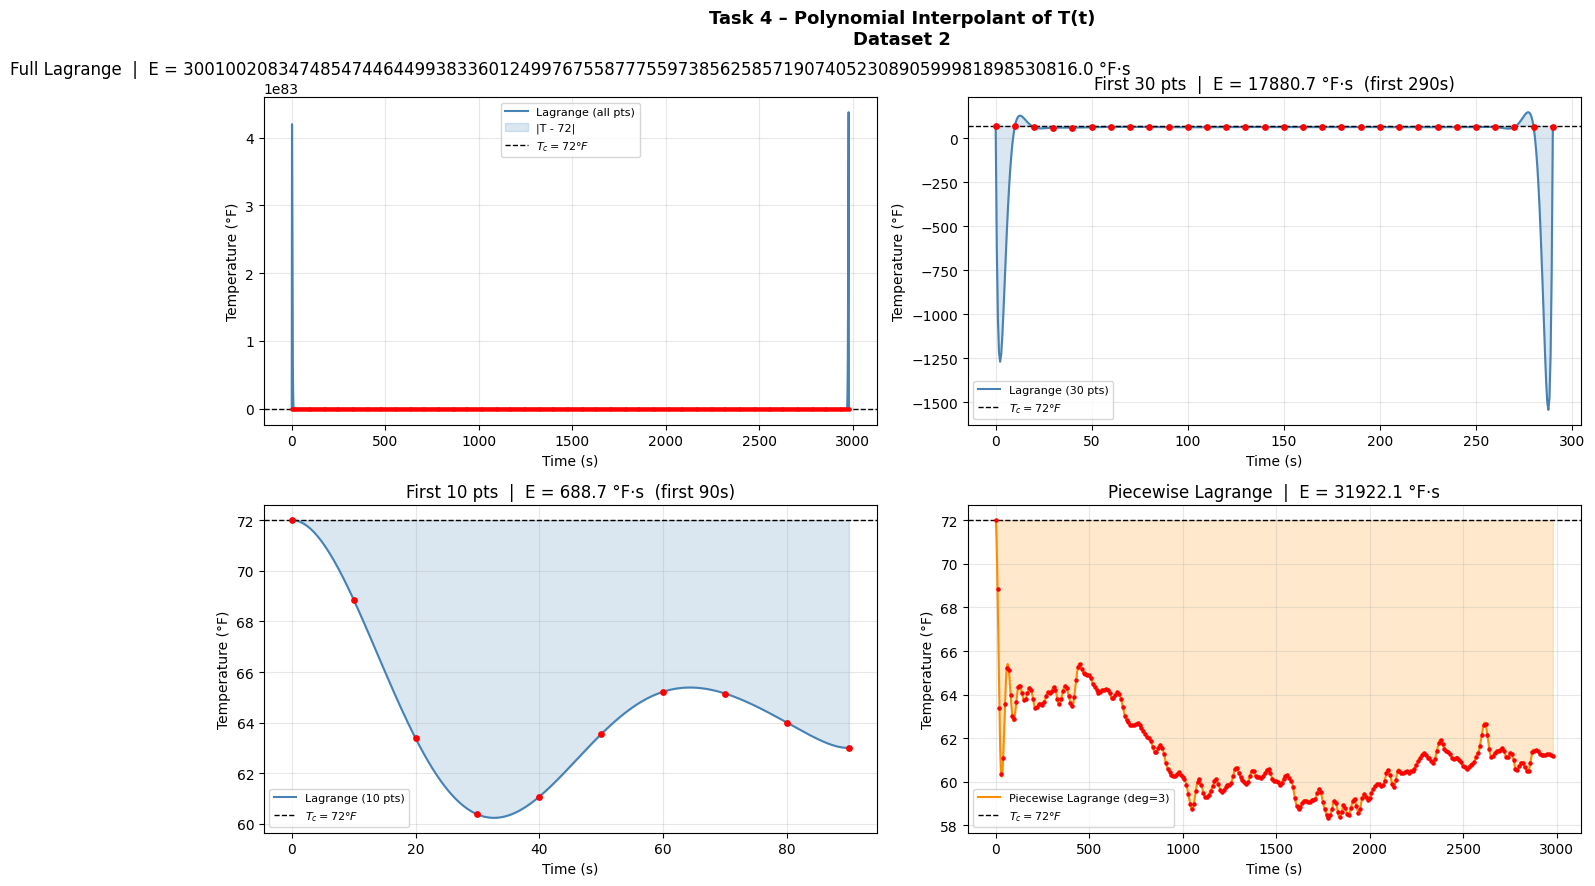


Dataset 3
  E (Full Lagrange, all pts):     12034786034413659620196204822534490928100927732965062114973576793596209370770022858752.00 °F·s
  E (Lagrange, first 30 pts):     641321.92 °F·s  [over first 290s only]
  E (Lagrange, first 10 pts):     657.30 °F·s  [over first 90s only]
  E (Piecewise Lagrange deg=3):   24919.12 °F·s


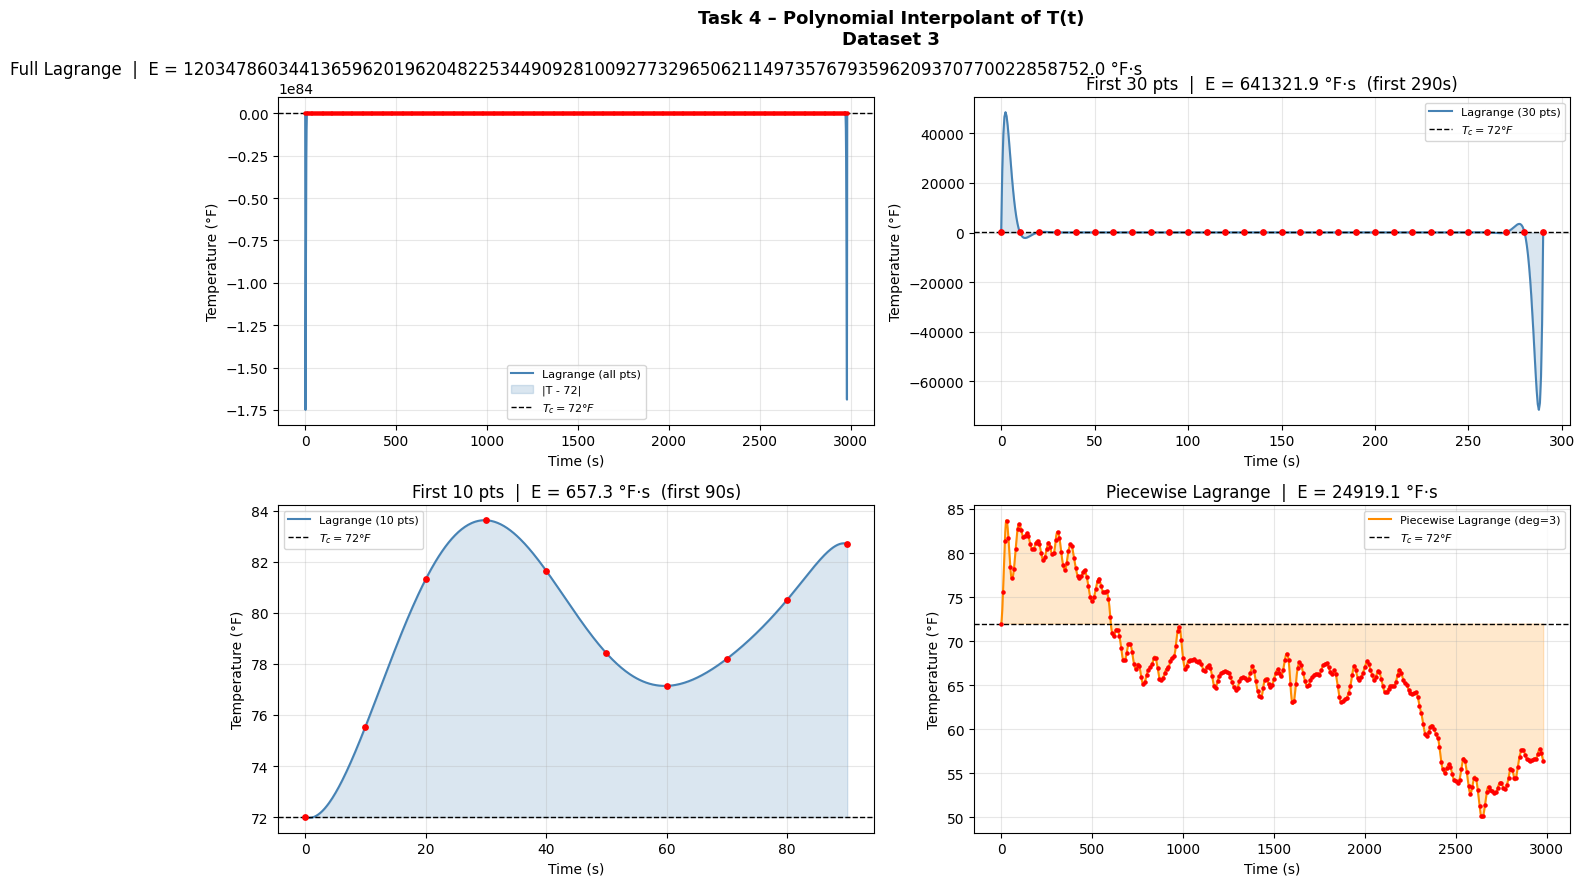

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
import json
from pathlib import Path


def load_task3_definitions(notebook_path='task3.ipynb'):
    """Load Task 3 data and solver definitions without running its plots."""
    notebook = json.loads(Path(notebook_path).read_text(encoding='utf-8'))
    code = '\n'.join(
        ''.join(cell.get('source', []))
        for cell in notebook['cells']
        if cell.get('cell_type') == 'code'
    )
    code = code.split('\nfor theta_data, name in zip(datasets, dataset_names):')[0]
    namespace = {}
    exec(code, namespace)
    return namespace


_task3 = load_task3_definitions()
datasets = _task3['datasets']
dataset_names = _task3['dataset_names']
solve_task3 = _task3['solve_task3']
alpha = _task3['alpha']
k = _task3['k']
dt_data = _task3['dt_data']

# ──────────────────────────────────────────────────────────────────────────────
# REUSE EXISTING LAGRANGE FUNCTIONS (same as Task 1.1)
# ──────────────────────────────────────────────────────────────────────────────

def lagrange_basis(t_val, i, t_nodes):
    result = 1.0
    for j in range(len(t_nodes)):
        if j != i:
            result *= (t_val - t_nodes[j]) / (t_nodes[i] - t_nodes[j])
    return result

def lagrange_interpolate(t_val, t_nodes, theta_nodes):
    return sum(float(theta_nodes[i]) * lagrange_basis(t_val, i, t_nodes)
               for i in range(len(t_nodes)))

# ──────────────────────────────────────────────────────────────────────────────
# INTEGRATION HELPER: trapezoid rule on |L(t) - Tc|
# ──────────────────────────────────────────────────────────────────────────────

Tc = 72.0

def integrate_exposure(t_fine, P_fine):
    """Trapezoid rule on |P(t) - Tc|."""
    return np.trapz(np.abs(P_fine - Tc), t_fine)

# ──────────────────────────────────────────────────────────────────────────────
# PIECEWISE LAGRANGE HELPER
# ──────────────────────────────────────────────────────────────────────────────

def piecewise_lagrange(t_fine, t_nodes, T_nodes, degree=3):
    """
    Evaluate piecewise Lagrange interpolant of given degree at t_fine points.
    Splits t_nodes into overlapping segments of (degree+1) points.
    """
    P_fine = np.zeros_like(t_fine)
    n = len(t_nodes)
    seg_size = degree + 1  # points per segment

    for start in range(0, n - 1, degree):
        end = min(start + seg_size, n)
        t_seg = t_nodes[start:end]
        T_seg = T_nodes[start:end]

        # Find t_fine points that fall in this segment
        if start == 0:
            mask = (t_fine >= t_seg[0]) & (t_fine <= t_seg[-1])
        else:
            mask = (t_fine > t_seg[0]) & (t_fine <= t_seg[-1])

        for idx in np.where(mask)[0]:
            P_fine[idx] = lagrange_interpolate(t_fine[idx], t_seg, T_seg)

    return P_fine

# ──────────────────────────────────────────────────────────────────────────────
# MAIN: Task 4 — Integration of Polynomial Interpolant of T(t)
# ──────────────────────────────────────────────────────────────────────────────

h = 1.0  # step size for solve_task3

for theta_data, name in zip(datasets, dataset_names):
    print(f"\n{'='*55}")
    print(f"{name}")
    print(f"{'='*55}")

    # Get T(t) from Task 3 solver
    t_solver, T_solver, _ = solve_task3(theta_data, h=h, alpha=alpha, k=k)

    # ── METHOD 1: Full Lagrange (all points) ──────────────────────────────────
    # Subsample to every 10th point to avoid extreme Runge — mirrors Task 1.1
    # "full data" approach (all ~300 pts would be unusable, so use solver output
    # at dt_data spacing = every 1/h * 10 = every 10 points)
    step = int(dt_data / h)
    t_nodes_full = t_solver[::step]
    T_nodes_full = T_solver[::step]

    t_fine = np.linspace(t_nodes_full[0], t_nodes_full[-1], 2000)
    P_full = np.array([lagrange_interpolate(tv, t_nodes_full, T_nodes_full)
                       for tv in t_fine])
    E_full = integrate_exposure(t_fine, P_full)

    # ── METHOD 2: First 30 points ─────────────────────────────────────────────
    t_nodes_30 = t_nodes_full[:30]
    T_nodes_30 = T_nodes_full[:30]
    t_fine_30  = np.linspace(t_nodes_30[0], t_nodes_30[-1], 500)
    P_30 = np.array([lagrange_interpolate(tv, t_nodes_30, T_nodes_30)
                     for tv in t_fine_30])
    E_30 = integrate_exposure(t_fine_30, P_30)

    # ── METHOD 3: First 10 points ─────────────────────────────────────────────
    t_nodes_10 = t_nodes_full[:10]
    T_nodes_10 = T_nodes_full[:10]
    t_fine_10  = np.linspace(t_nodes_10[0], t_nodes_10[-1], 500)
    P_10 = np.array([lagrange_interpolate(tv, t_nodes_10, T_nodes_10)
                     for tv in t_fine_10])
    E_10 = integrate_exposure(t_fine_10, P_10)

    # ── METHOD 4: Piecewise Lagrange (degree 3, full interval) ───────────────
    P_pw = piecewise_lagrange(t_fine, t_nodes_full, T_nodes_full, degree=3)
    E_pw = integrate_exposure(t_fine, P_pw)

    # ── PRINT RESULTS ─────────────────────────────────────────────────────────
    print(f"  E (Full Lagrange, all pts):     {E_full:.2f} °F·s")
    print(f"  E (Lagrange, first 30 pts):     {E_30:.2f} °F·s  [over first 290s only]")
    print(f"  E (Lagrange, first 10 pts):     {E_10:.2f} °F·s  [over first 90s only]")
    print(f"  E (Piecewise Lagrange deg=3):   {E_pw:.2f} °F·s")

    # ── PLOTS (mirroring Task 1.1 style) ─────────────────────────────────────
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    fig.suptitle(f'Task 4 – Polynomial Interpolant of T(t)\n{name}', 
                 fontsize=13, fontweight='bold')

    # Full Lagrange
    ax = axes[0, 0]
    ax.plot(t_fine, P_full, color='steelblue', label='Lagrange (all pts)')
    ax.fill_between(t_fine, Tc, P_full, alpha=0.2, color='steelblue', label='|T - 72|')
    ax.axhline(Tc, color='k', linestyle='--', linewidth=1, label='$T_c = 72°F$')
    ax.scatter(t_nodes_full, T_nodes_full, color='red', s=5, zorder=5)
    ax.set_title(f'Full Lagrange  |  E = {E_full:.1f} °F·s')
    ax.set_xlabel('Time (s)'); ax.set_ylabel('Temperature (°F)')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    # 30 points
    ax = axes[0, 1]
    ax.plot(t_fine_30, P_30, color='steelblue', label='Lagrange (30 pts)')
    ax.fill_between(t_fine_30, Tc, P_30, alpha=0.2, color='steelblue')
    ax.axhline(Tc, color='k', linestyle='--', linewidth=1, label='$T_c = 72°F$')
    ax.scatter(t_nodes_30, T_nodes_30, color='red', s=15, zorder=5)
    ax.set_title(f'First 30 pts  |  E = {E_30:.1f} °F·s  (first 290s)')
    ax.set_xlabel('Time (s)'); ax.set_ylabel('Temperature (°F)')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    # 10 points
    ax = axes[1, 0]
    ax.plot(t_fine_10, P_10, color='steelblue', label='Lagrange (10 pts)')
    ax.fill_between(t_fine_10, Tc, P_10, alpha=0.2, color='steelblue')
    ax.axhline(Tc, color='k', linestyle='--', linewidth=1, label='$T_c = 72°F$')
    ax.scatter(t_nodes_10, T_nodes_10, color='red', s=15, zorder=5)
    ax.set_title(f'First 10 pts  |  E = {E_10:.1f} °F·s  (first 90s)')
    ax.set_xlabel('Time (s)'); ax.set_ylabel('Temperature (°F)')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    # Piecewise Lagrange
    ax = axes[1, 1]
    ax.plot(t_fine, P_pw, color='darkorange', label='Piecewise Lagrange (deg=3)')
    ax.fill_between(t_fine, Tc, P_pw, alpha=0.2, color='darkorange')
    ax.axhline(Tc, color='k', linestyle='--', linewidth=1, label='$T_c = 72°F$')
    ax.scatter(t_nodes_full, T_nodes_full, color='red', s=5, zorder=5)
    ax.set_title(f'Piecewise Lagrange  |  E = {E_pw:.1f} °F·s')
    ax.set_xlabel('Time (s)'); ax.set_ylabel('Temperature (°F)')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()